# Cuffless AI — Data Exploration

This notebook is for **understanding and visualizing `Part_1.mat` before doing any machine learning**.

Expected structure:

```text
repo/
├── data/
│   └── Part_1.mat
└── notebook/
    └── cuffless_ai_data_exploration.ipynb
```


## 1. Imports

In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


## 2. Locate the dataset

Because the notebook is inside `notebooks/` and `data/` is beside that folder, we define the paths to all four dataset files.


In [ ]:
filename_part_1 = Path("../data/Part_1.mat")
filename_part_2 = Path("../data/Part_2.mat")
filename_part_3 = Path("../data/Part_3.mat")
filename_part_4 = Path("../data/Part_4.mat")

data_files = [filename_part_1, filename_part_2, filename_part_3, filename_part_4]

for filename in data_files:
    print(filename.name, "exists:", filename.exists())

if not all(filename.exists() for filename in data_files):
    raise FileNotFoundError("Put all four Part_*.mat files inside the data/ folder.")

# Keep Part_1 selected for the next cell.
filename = filename_part_1

## 3. Inspect the top-level HDF5 structure

In [3]:
with h5py.File(filename, "r") as f:
    print("Top-level objects:")
    for key in f.keys():
        obj = f[key]
        print(f"  {key}: type={type(obj).__name__}, shape={getattr(obj, 'shape', None)}")

Top-level objects:
  #refs#: type=Group, shape=None
  Part_1: type=Dataset, shape=(3000, 1)


## 4. Inspect `Part_1`

`Part_1` contains references to the real recordings.


In [4]:
with h5py.File(filename, "r") as f:
    part1 = f["Part_1"]
    print("Object type:", type(part1))
    print("Shape:", part1.shape)
    print("Data type:", part1.dtype)
    print("Number of records:", part1.shape[0])

Object type: <class 'h5py._hl.dataset.Dataset'>
Shape: (3000, 1)
Data type: object
Number of records: 3000


## 5. Open the first real recording

In [5]:
with h5py.File(filename, "r") as f:
    part1 = f["Part_1"]
    first_record_ref = part1[0, 0]
    first_record = np.array(f[first_record_ref])

print("Raw shape:", first_record.shape)

if first_record.ndim != 2:
    raise ValueError(f"Expected a 2D recording, got {first_record.shape}")

if first_record.shape[1] == 3:
    record = first_record
elif first_record.shape[0] == 3:
    record = first_record.T
else:
    record = first_record
    print("Warning: expected one dimension to contain 3 channels.")

print("Working shape (samples x channels):", record.shape)

Raw shape: (61000, 3)
Working shape (samples x channels): (61000, 3)


## 6. View the actual numbers

The dataset documentation identifies the three columns, in order, as PPG, ABP, and ECG.


In [6]:
column_names = ["PPG", "ABP", "ECG"]
df = pd.DataFrame(record, columns=column_names)
df.head(20)

,Channel 1,Channel 2,Channel 3
0,1.759531,67.062955,-0.060606
1,1.718475,69.358628,-0.075269
2,1.684262,75.366453,-0.070381
3,1.657869,85.037586,-0.035191
4,1.637341,96.222885,0.024438
5,1.615836,105.942862,0.089932
6,1.593353,112.927569,0.154936
7,1.570870,117.665447,0.204790
8,1.549365,120.986846,0.249756
9,1.526882,123.184831,0.274682


## 7. Recording size and duration

In [7]:
FS = 125  # samples per second

num_samples = len(df)
num_channels = df.shape[1]
duration_seconds = num_samples / FS

print("Samples:", num_samples)
print("Channels:", num_channels)
print(f"Duration: {duration_seconds:.2f} seconds")
print(f"Duration: {duration_seconds / 60:.2f} minutes")

Samples: 61000
Channels: 3
Duration: 488.00 seconds
Duration: 8.13 minutes


## 8. Summary statistics

In [8]:
df.describe()

,Channel 1,Channel 2,Channel 3
count,61000.000000,61000.000000,61000.000000
mean,1.839741,94.657665,0.225842
std,0.631981,20.566707,0.254658
min,0.000000,50.162895,-0.240469
25%,1.309873,78.541320,0.089932
50%,1.623656,86.258688,0.184751
75%,2.422287,112.927569,0.304985
max,4.001955,160.110974,1.500978


## 9. Plot the first 5 seconds

At 125 Hz, 5 seconds = 625 samples.


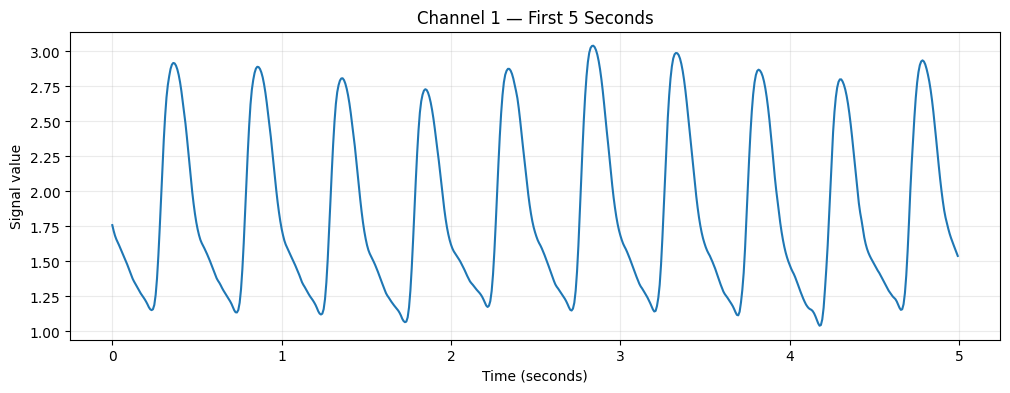

In [9]:
SECONDS_TO_SHOW = 5
samples_to_show = min(FS * SECONDS_TO_SHOW, len(df))
time = np.arange(samples_to_show) / FS

plt.figure(figsize=(12, 4))
plt.plot(time, df["PPG"].iloc[:samples_to_show])
plt.title("PPG — First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal value")
plt.grid(True, alpha=0.25)
plt.show()

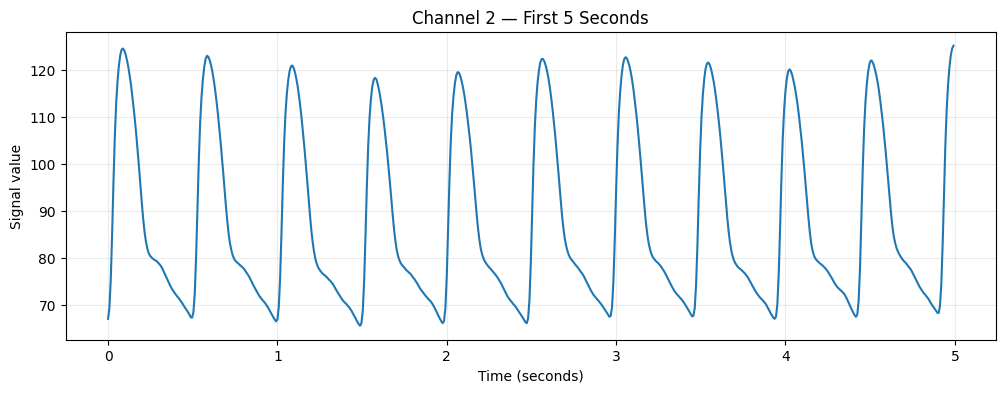

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(time, df["ABP"].iloc[:samples_to_show])
plt.title("ABP — First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal value")
plt.grid(True, alpha=0.25)
plt.show()

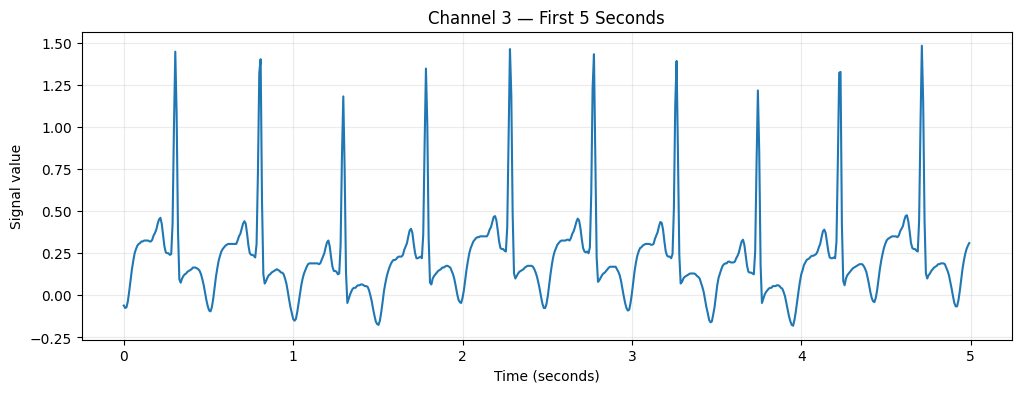

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(time, df["ECG"].iloc[:samples_to_show])
plt.title("ECG — First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal value")
plt.grid(True, alpha=0.25)
plt.show()

## 10. Look at more rows

In [12]:
df.head(50)

,Channel 1,Channel 2,Channel 3
0,1.759531,67.062955,-0.060606
1,1.718475,69.358628,-0.075269
2,1.684262,75.366453,-0.070381
3,1.657869,85.037586,-0.035191
4,1.637341,96.222885,0.024438
5,1.615836,105.942862,0.089932
6,1.593353,112.927569,0.154936
7,1.570870,117.665447,0.204790
8,1.549365,120.986846,0.249756
9,1.526882,123.184831,0.274682
